# [LAB 10] 1-1. 단순로지스틱 회귀
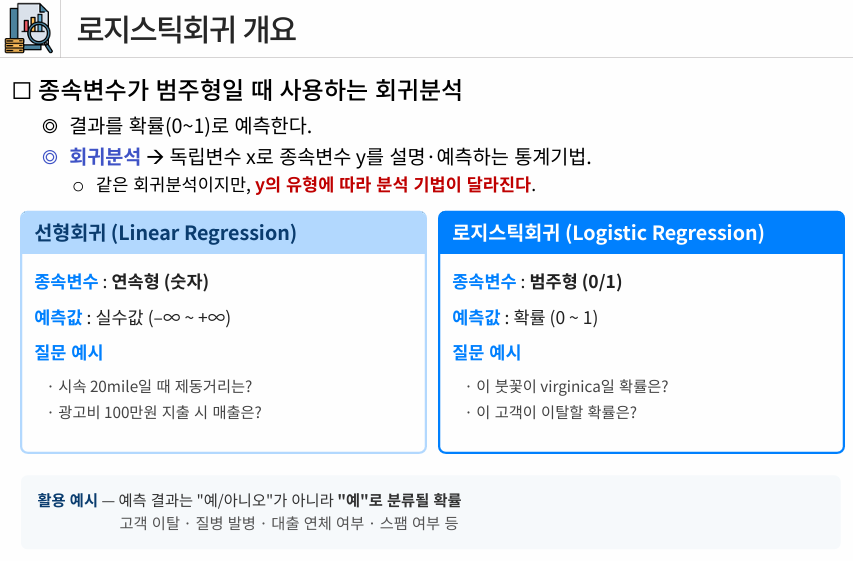
## #01. 준비작업
### 1. 라이브러리 참조

In [30]:
# 라이브러리 기본 참조
from hossam import load_data
from helpers import *
import numpy as np
from pandas import DataFrame

# 로지스틱회귀를 위한 참조
from statsmodels.api import add_constant, Logit
from statsmodels.formula.api import logit as formula_logit

### 2. 데이터 가져오기

In [31]:
origin = load_data('iris_bin')
origin.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)



,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,versicolor
1,6.400,3.200,4.500,1.500,versicolor
2,6.900,3.100,4.900,1.500,versicolor
3,5.500,2.300,4.000,1.300,versicolor
4,6.500,2.800,4.600,1.500,versicolor


### 3. 데이터 전처리
- 단순선형회귀와 단순로지스틱을 비교하기 위해 독립변수 1개, 종속변수 1개인 형태로 전처리를 수행한다.
- 종속변수를 0과 1로 라벨링한다.

In [49]:
df = origin[['Sepal_Length', 'Species']]
df = my_prep.labeling(df, columns=['Species'])
df.head()

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Species
0,7.000,0
1,6.400,0
2,6.900,0
3,5.500,0
4,6.500,0


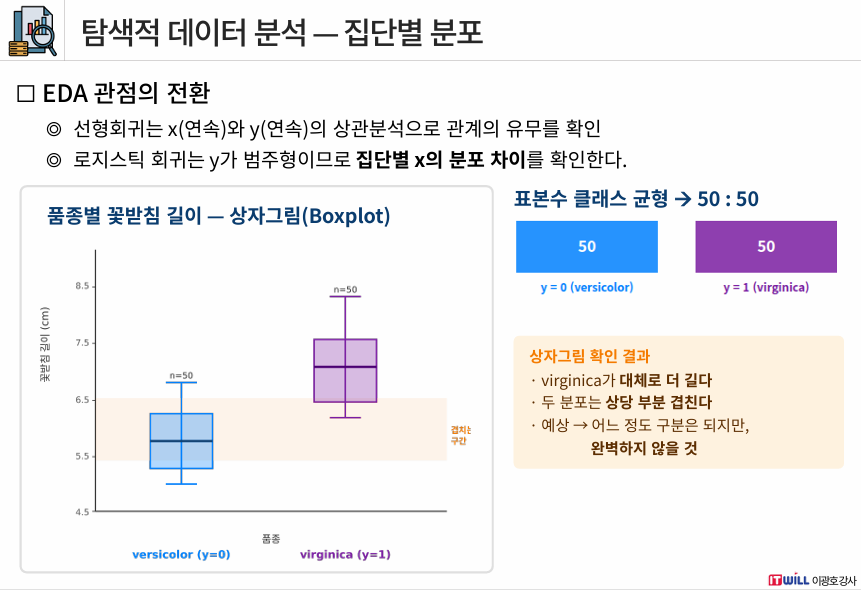

## #02. 탐색적 데이터 분석
### 1. 종속변수의 분포 확인
- 두 범주의 빈도가 비슷한지(클래스 균형) 확인한다.
- 한쪽으로 심하게 치우쳐 있으면 정확도가 높아 보여도 실제로는 쓸모없는 모형이 될 수 있다.

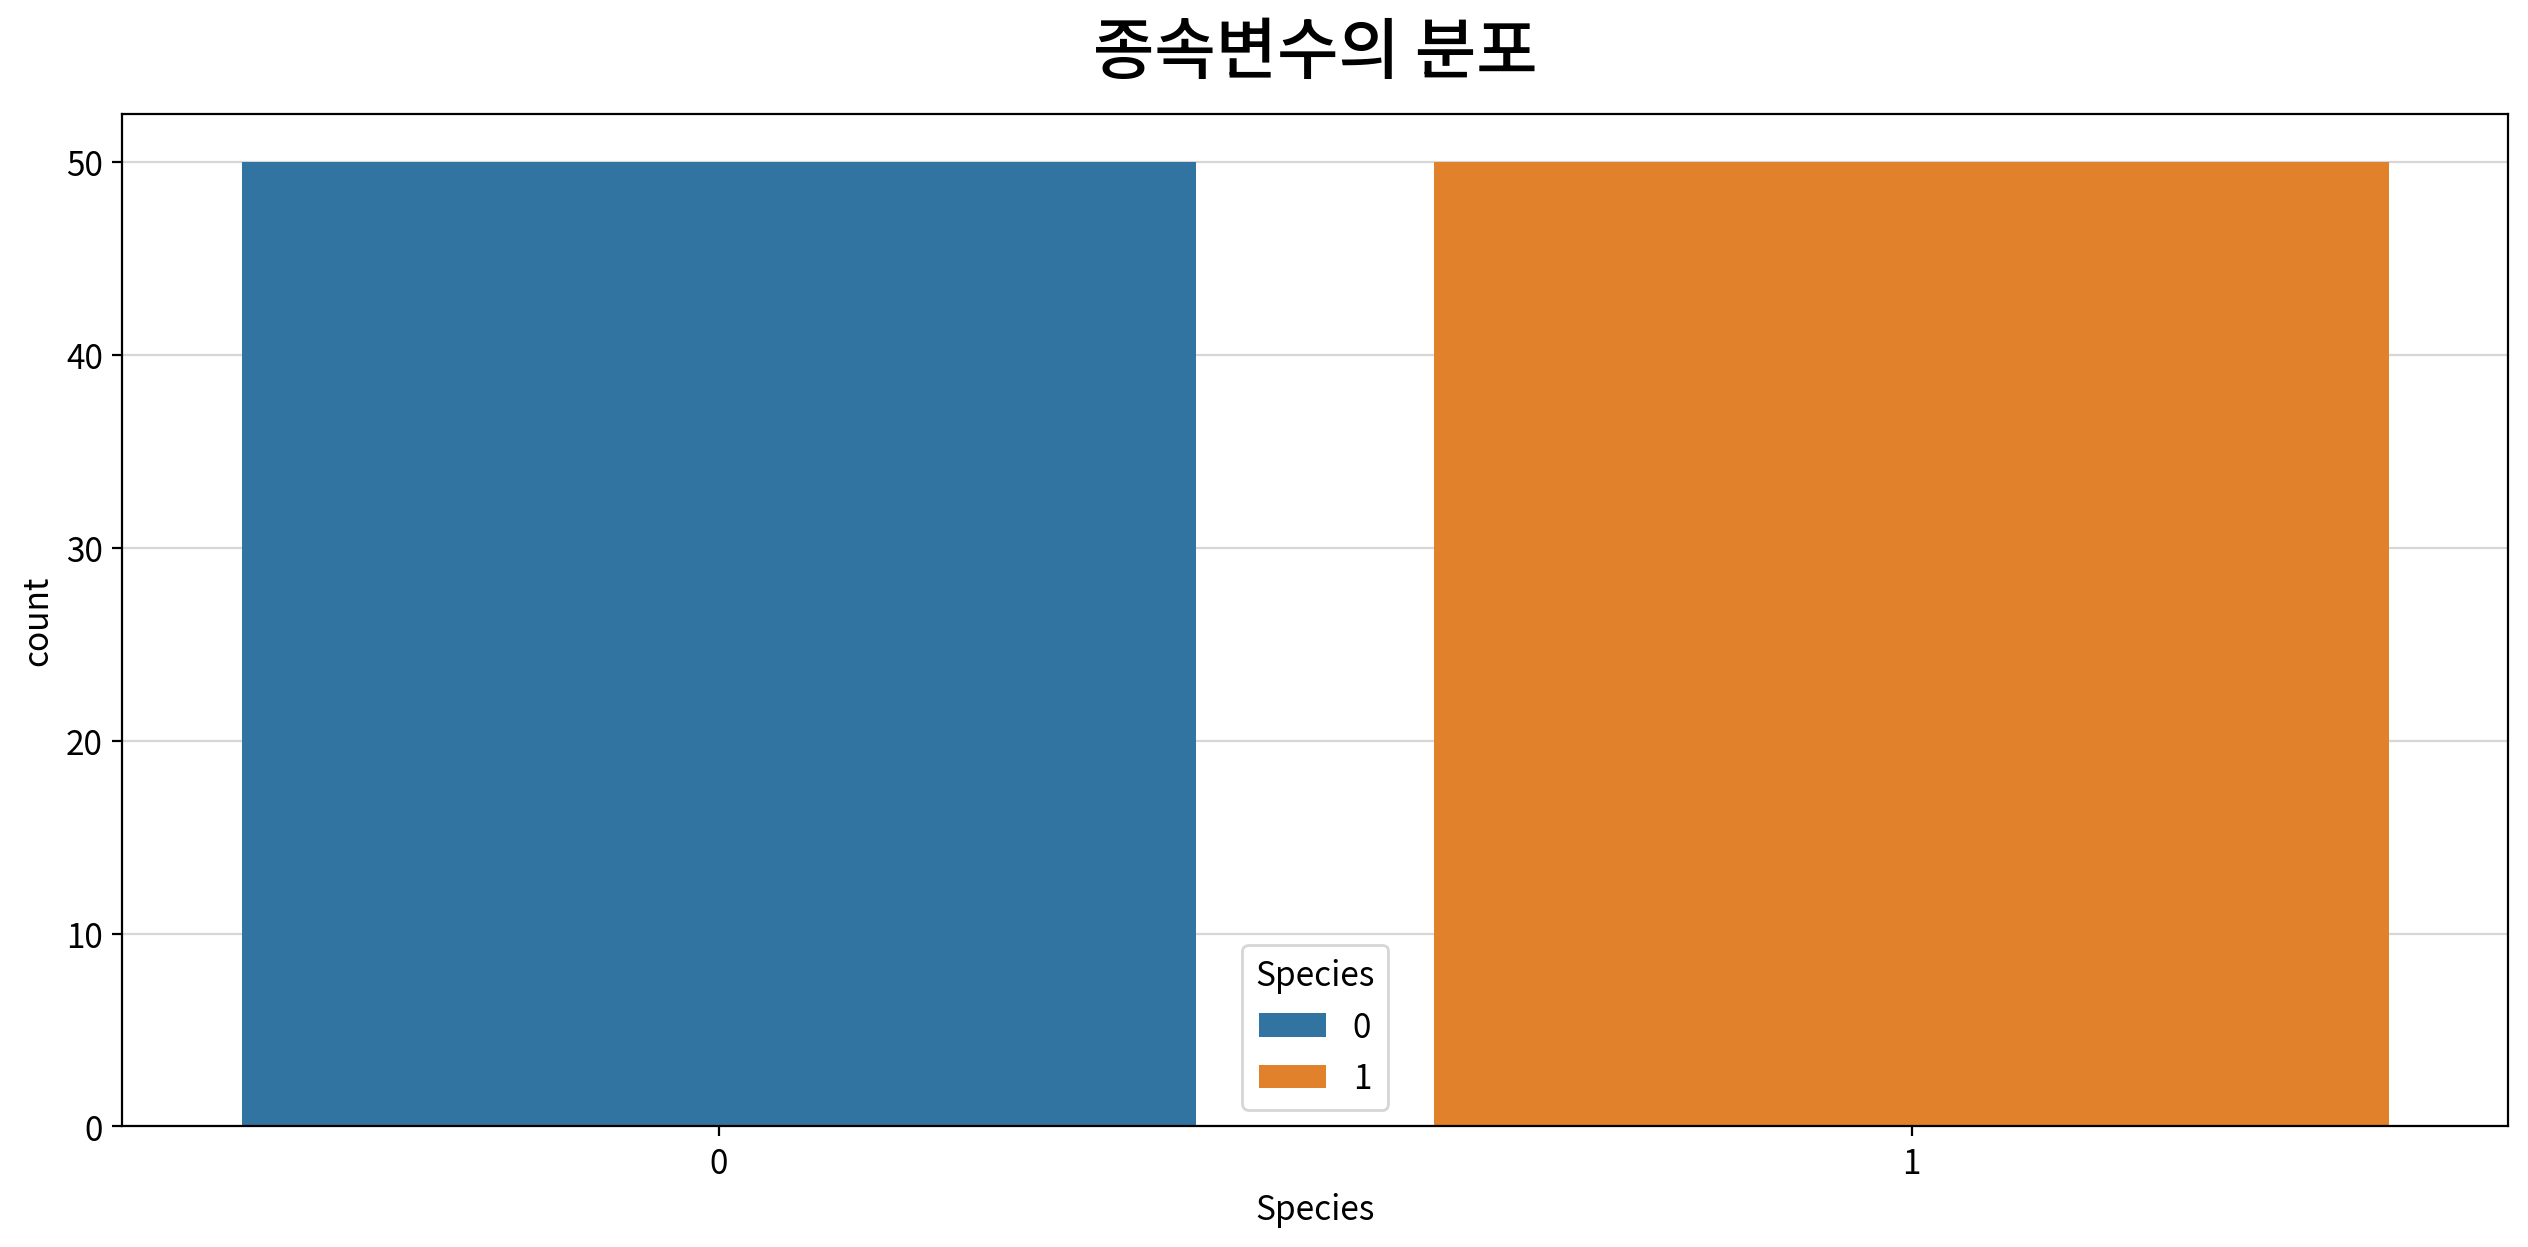

In [33]:
my_plot.countplot(df, x='Species', hue='Species', title='종속변수의 분포')

- 인사이트 : 두 범주가 균형을 이루고 있다.

### 2. 집단별 독립변수의 분포 비교
- 품종에 다라 꽃받침 길이(Sepal_Length)의 분포가 다른지 확인한다.
- 분포가 다를수록 좋은 독립변수이다.

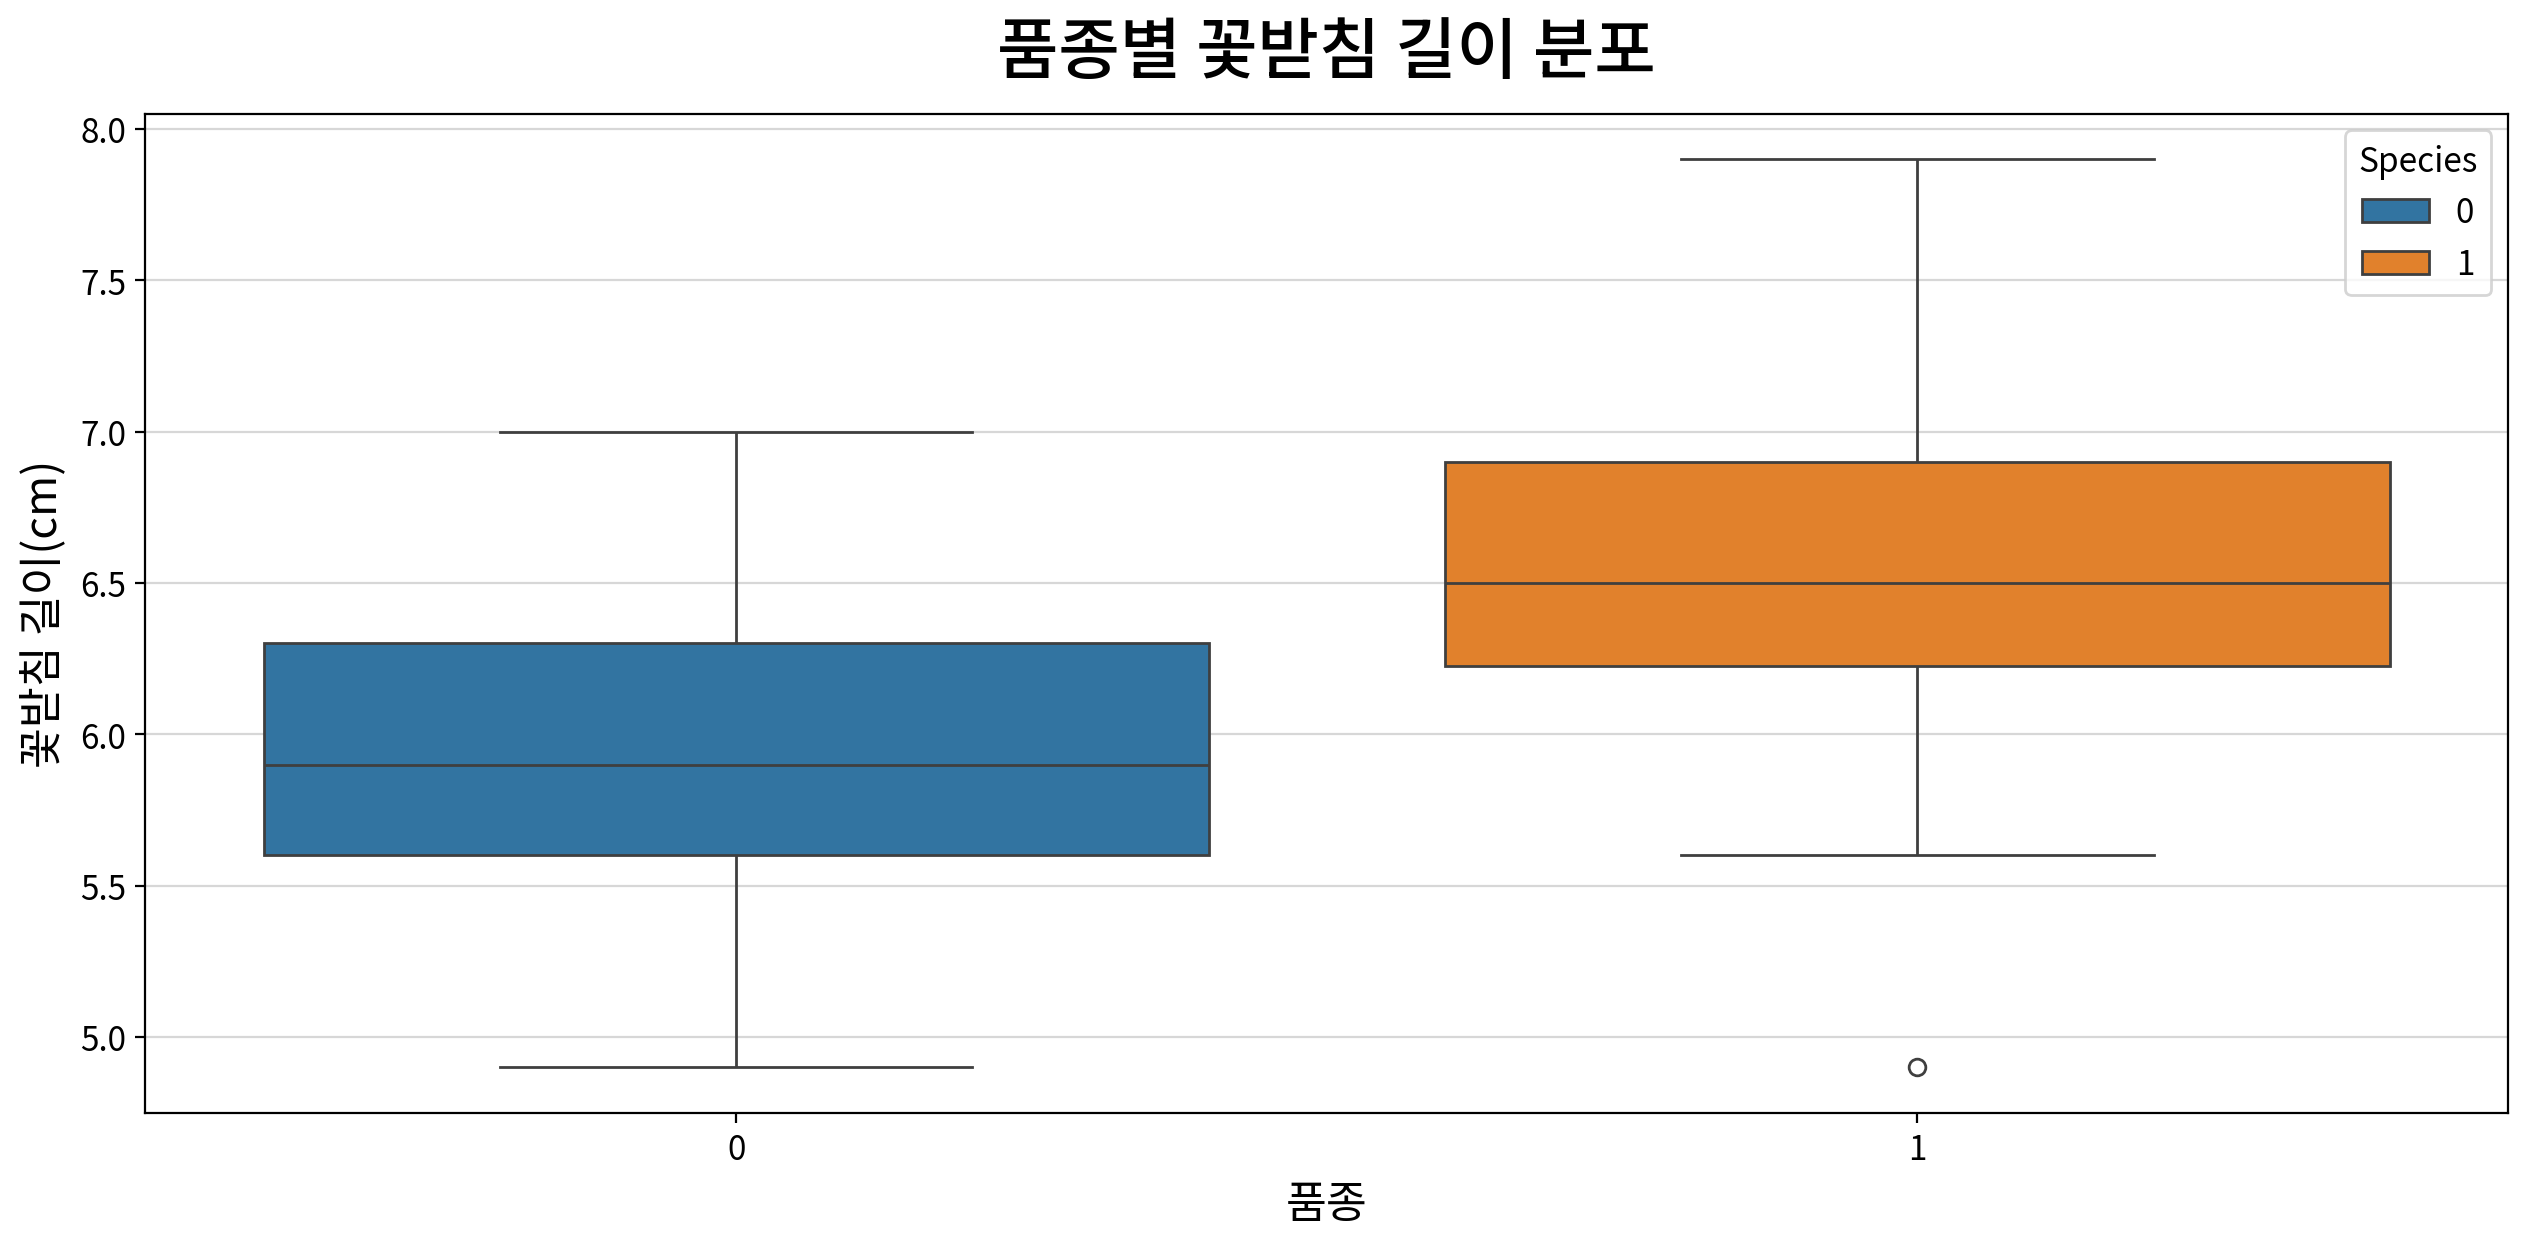

In [34]:
my_plot.boxplot(df, x='Species', y='Sepal_Length', hue='Species',
                title='품종별 꽃받침 길이 분포', xlabel='품종',
                ylabel='꽃받침 길이(cm)')

- 인사이트
    - virginica의 꽃받침이 versicolor보다 대체로 길지만, 두 상자가 상당 부분 겹쳐 있다.
    - 즉, 꽃받침 길이만으로 두 품종을 어느 정도 구분할 수는 있으나 완벽하지는 않을 것으로 보인다.

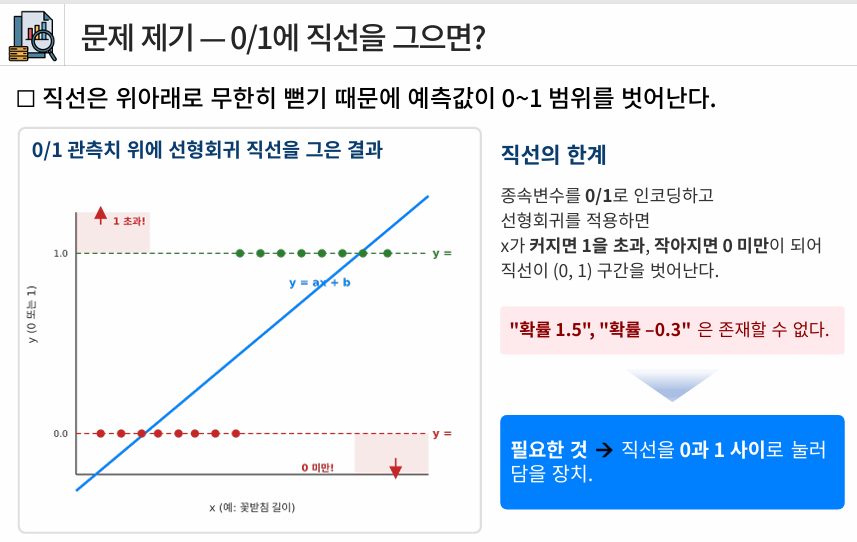

## #03. 로지스틱 회귀의 이해
### 1. 단순선형회귀로 접근

In [35]:
ols_fit = my_ols.auto_ols(df, y='Species', report=True, test=False)

#### ▶ 모형 적합도

,종속변수,독립변수,B,표준오차,β,t,유의확률,공차,VIF
0,Species,Sepal_Length,0.375,0.067,0.494,5.629,0.000,1.000,1.000


**Note. n = 100. F(1, 98) = 31.69, p < 0.001, R² = 0.244, Adj.R² = 0.237, Durbin_Watson = 0.535**

Species를 종속변수로, Sepal_Length(을)를 독립변수로 한 단순선형회귀분석 결과, 모형은 통계적으로 유의하였다.

> F(1, 98) = 31.69 , p < 0.001, R² = 0.244.

즉, Sepal_Length는 Species의 약 24.43%를 설명하는 것으로 나타났다.

### 2. 단순선형회귀의 예측값 생성

In [36]:
# 임의의 꽃받침 길이(4~9)에 대한 직선의 예측값 30개
np.random.seed(1234)  # 실행할 때마다 같은 결과가 나오도록 고정
sample = DataFrame({'Sepal_Length' : [np.random.uniform(4,9) for _ in range(30)]})
sample['예측값'] = ols_fit.predict(add_constant(sample))
sample.head()

,Sepal_Length,예측값
0,4.958,0.011
1,7.111,0.818
2,6.189,0.473
3,7.927,1.124
4,7.900,1.114


### 3. 실제 데이터와 예측 결과 시각화

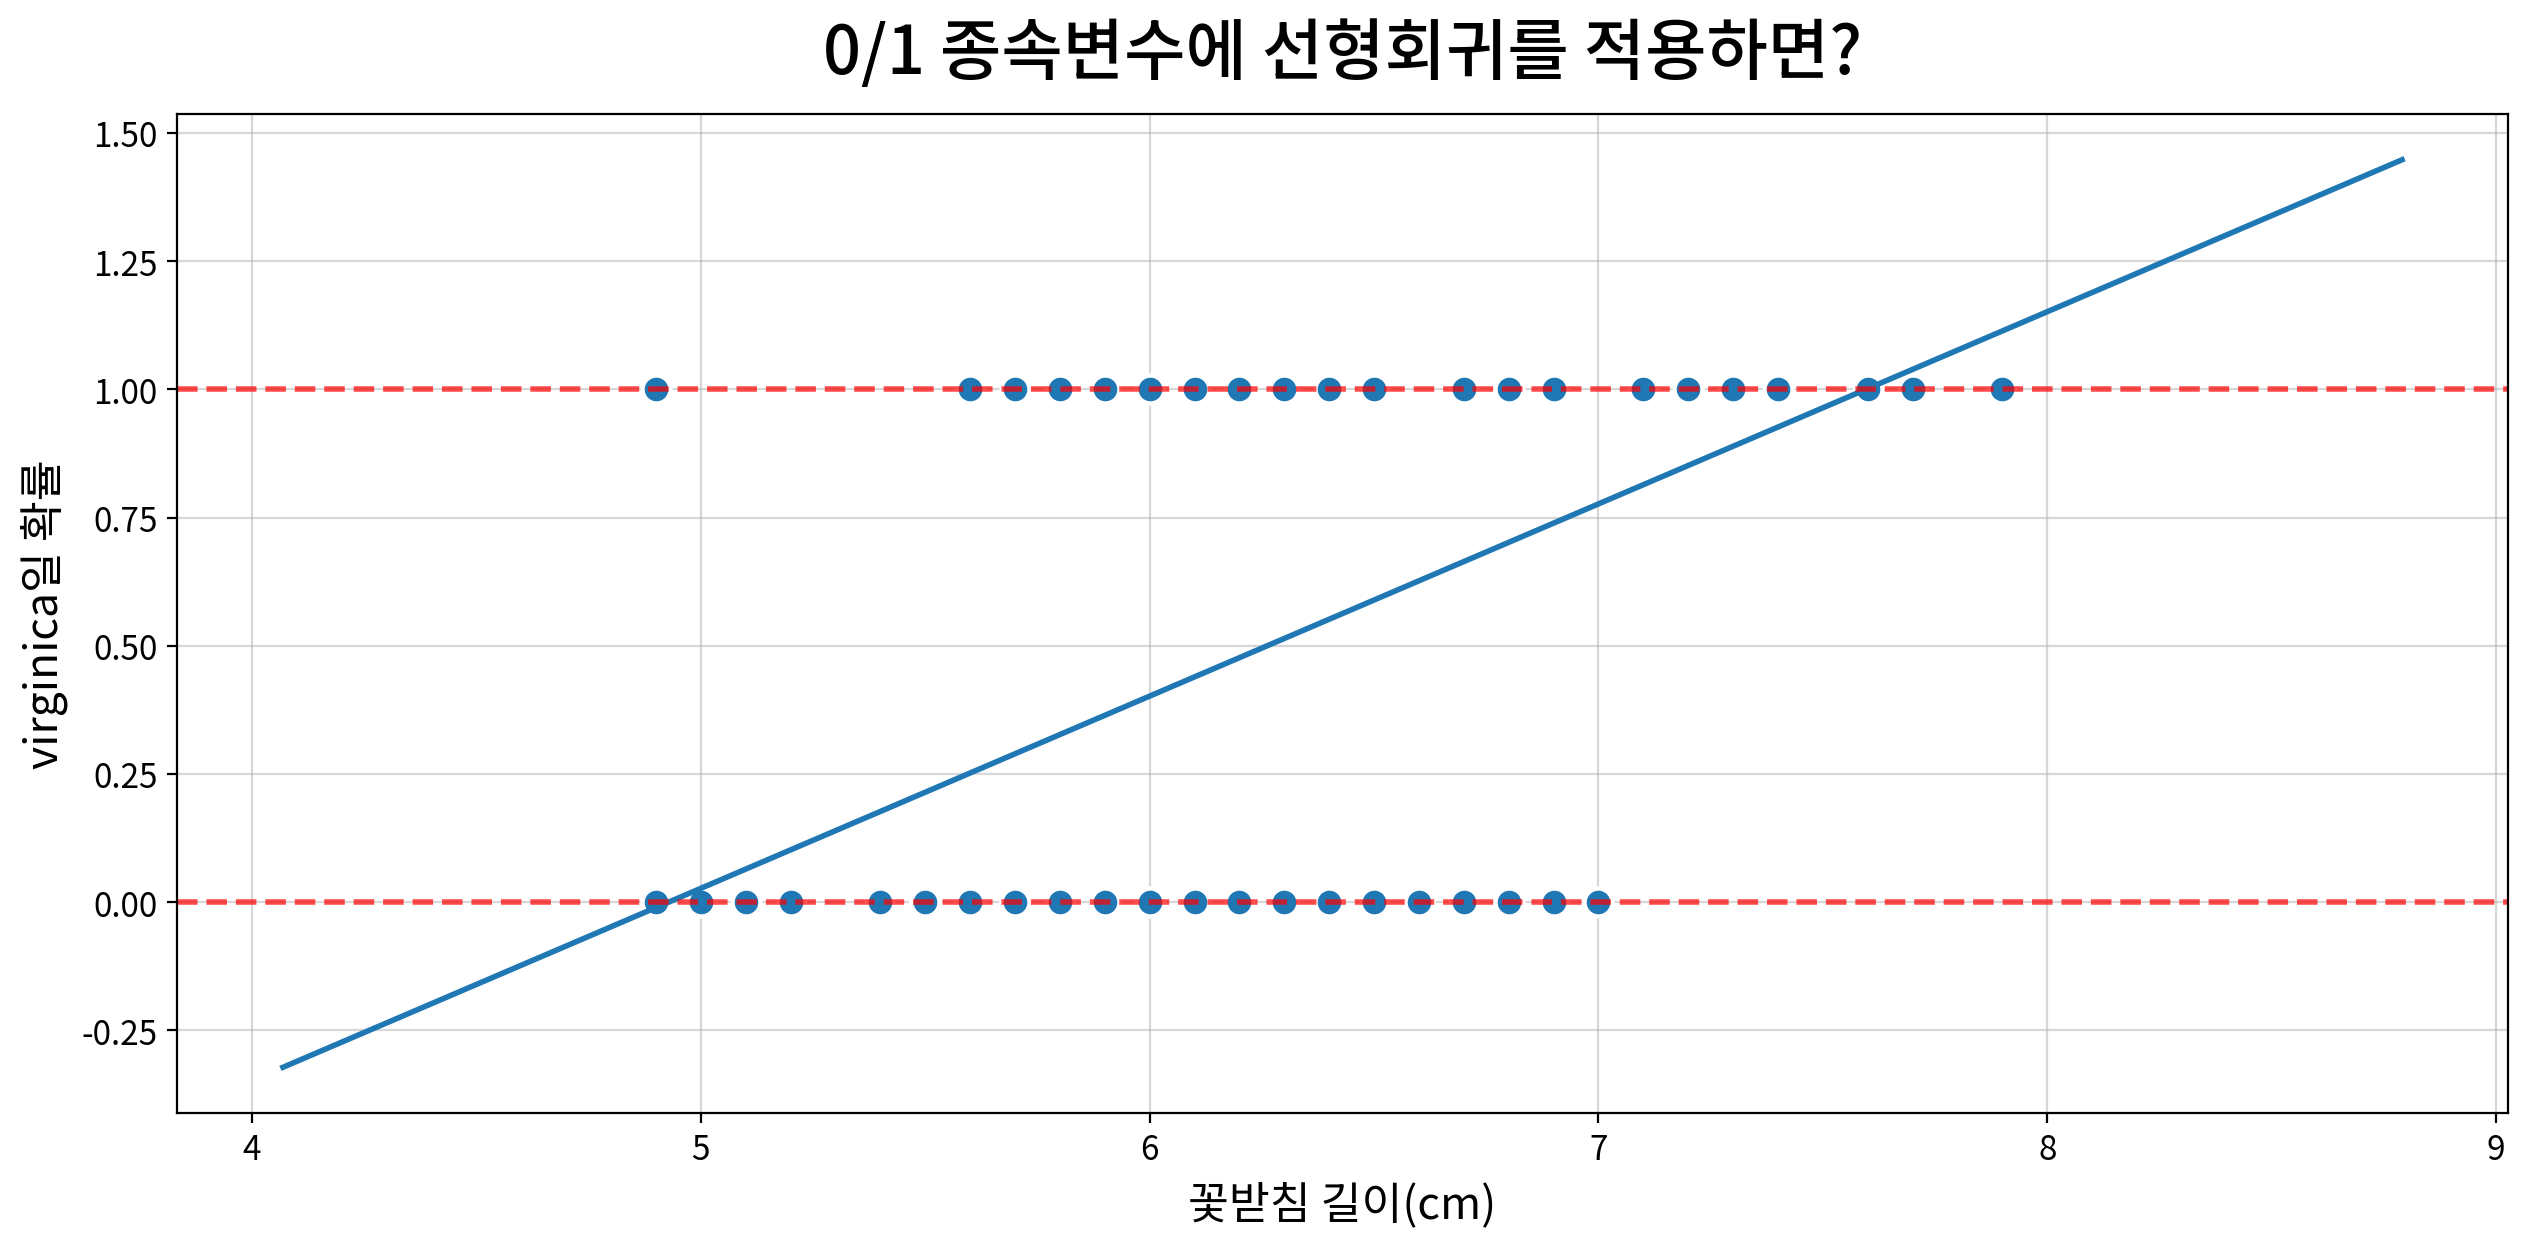

In [37]:
# 시각화 : 실제 관측치(0/1) + 선형회귀 직선
fig, ax = my_plot.init(title='0/1 종속변수에 선형회귀를 적용하면?', xlabel='꽃받침 길이(cm)', ylabel='virginica일 확률')

# 실제 관측치는 0 또는 1, 두 개의 높이에만 찍힌다.
my_plot.scatterplot(df, x='Sepal_Length', y='Species', ax=ax)

# 선형회귀가 찾아낸 직선
my_plot.lineplot(sample, x='Sepal_Length', y='예측값', ax=ax)

# 확률이 존재할 수 있는 범위(0~1)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)

my_plot.show()

- 인사이트
    - 직선의 한계 : 직선은 0과 1 사이에 머무를 수 없다.
        - 그래프의 좌측 끝과 우측 끝에서 직선이 빨간 점선(0과 1)을 뚫고 나간다.
        - 실제 관측치는 0 아니면 1인데, 직선은 그 사이를 일정한 기울기로 지나갈 뿐이라 데이터의 모양과도 맞지 않는다.
    - 필요한 것은 무엇인가?
        - 아무리 큰 값을 넣어도 1을 넘지 않고, 아무리 작은 값을 넣어도 0 아래도 내려가지 않는 곡선
        - 즉, 직선 ax+b를 0과 1 사이로 눌러 담는 S자 곡선이 필요하다 → 로지스틱회귀

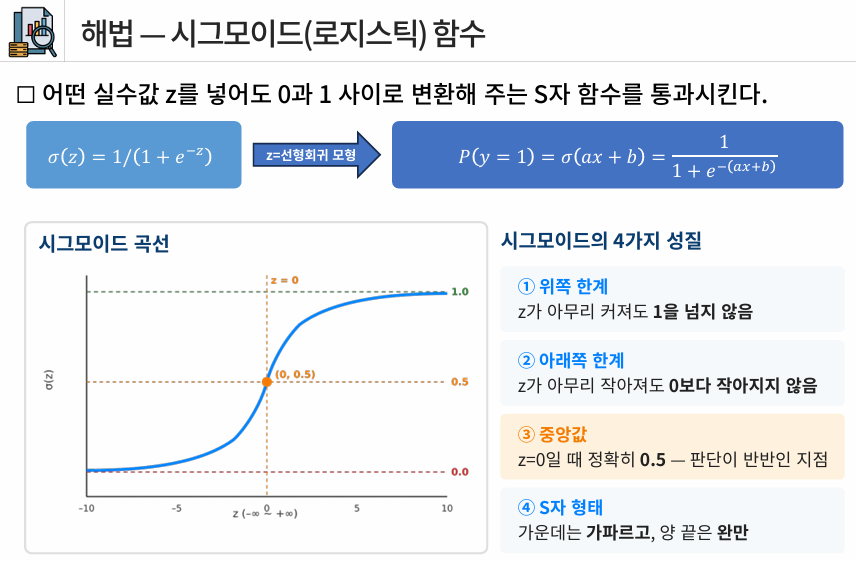

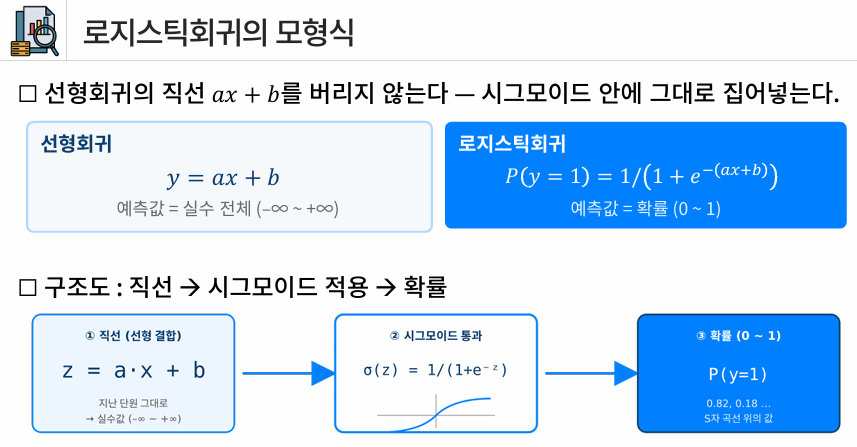

### 4. 선형회귀의 예측값을 시그모이드에 통과시키기
- 앞에서 만든 직예측값을 그대로 σ(z)에 넣어본다.
    - 확률로 볼 수 없었던 값들이 0과 1 사이로 눌러 담기는지 확인한다.

In [38]:
sample['σ(z)'] = 1 / (1 + np.exp(-sample['예측값']))
sample['result'] = sample['σ(z)'].round()
sample.head()

,Sepal_Length,예측값,σ(z),result
0,4.958,0.011,0.503,1.000
1,7.111,0.818,0.694,1.000
2,6.189,0.473,0.616,1.000
3,7.927,1.124,0.755,1.000
4,7.900,1.114,0.753,1.000


### 5. 시그모이드 적용 결과 시각화

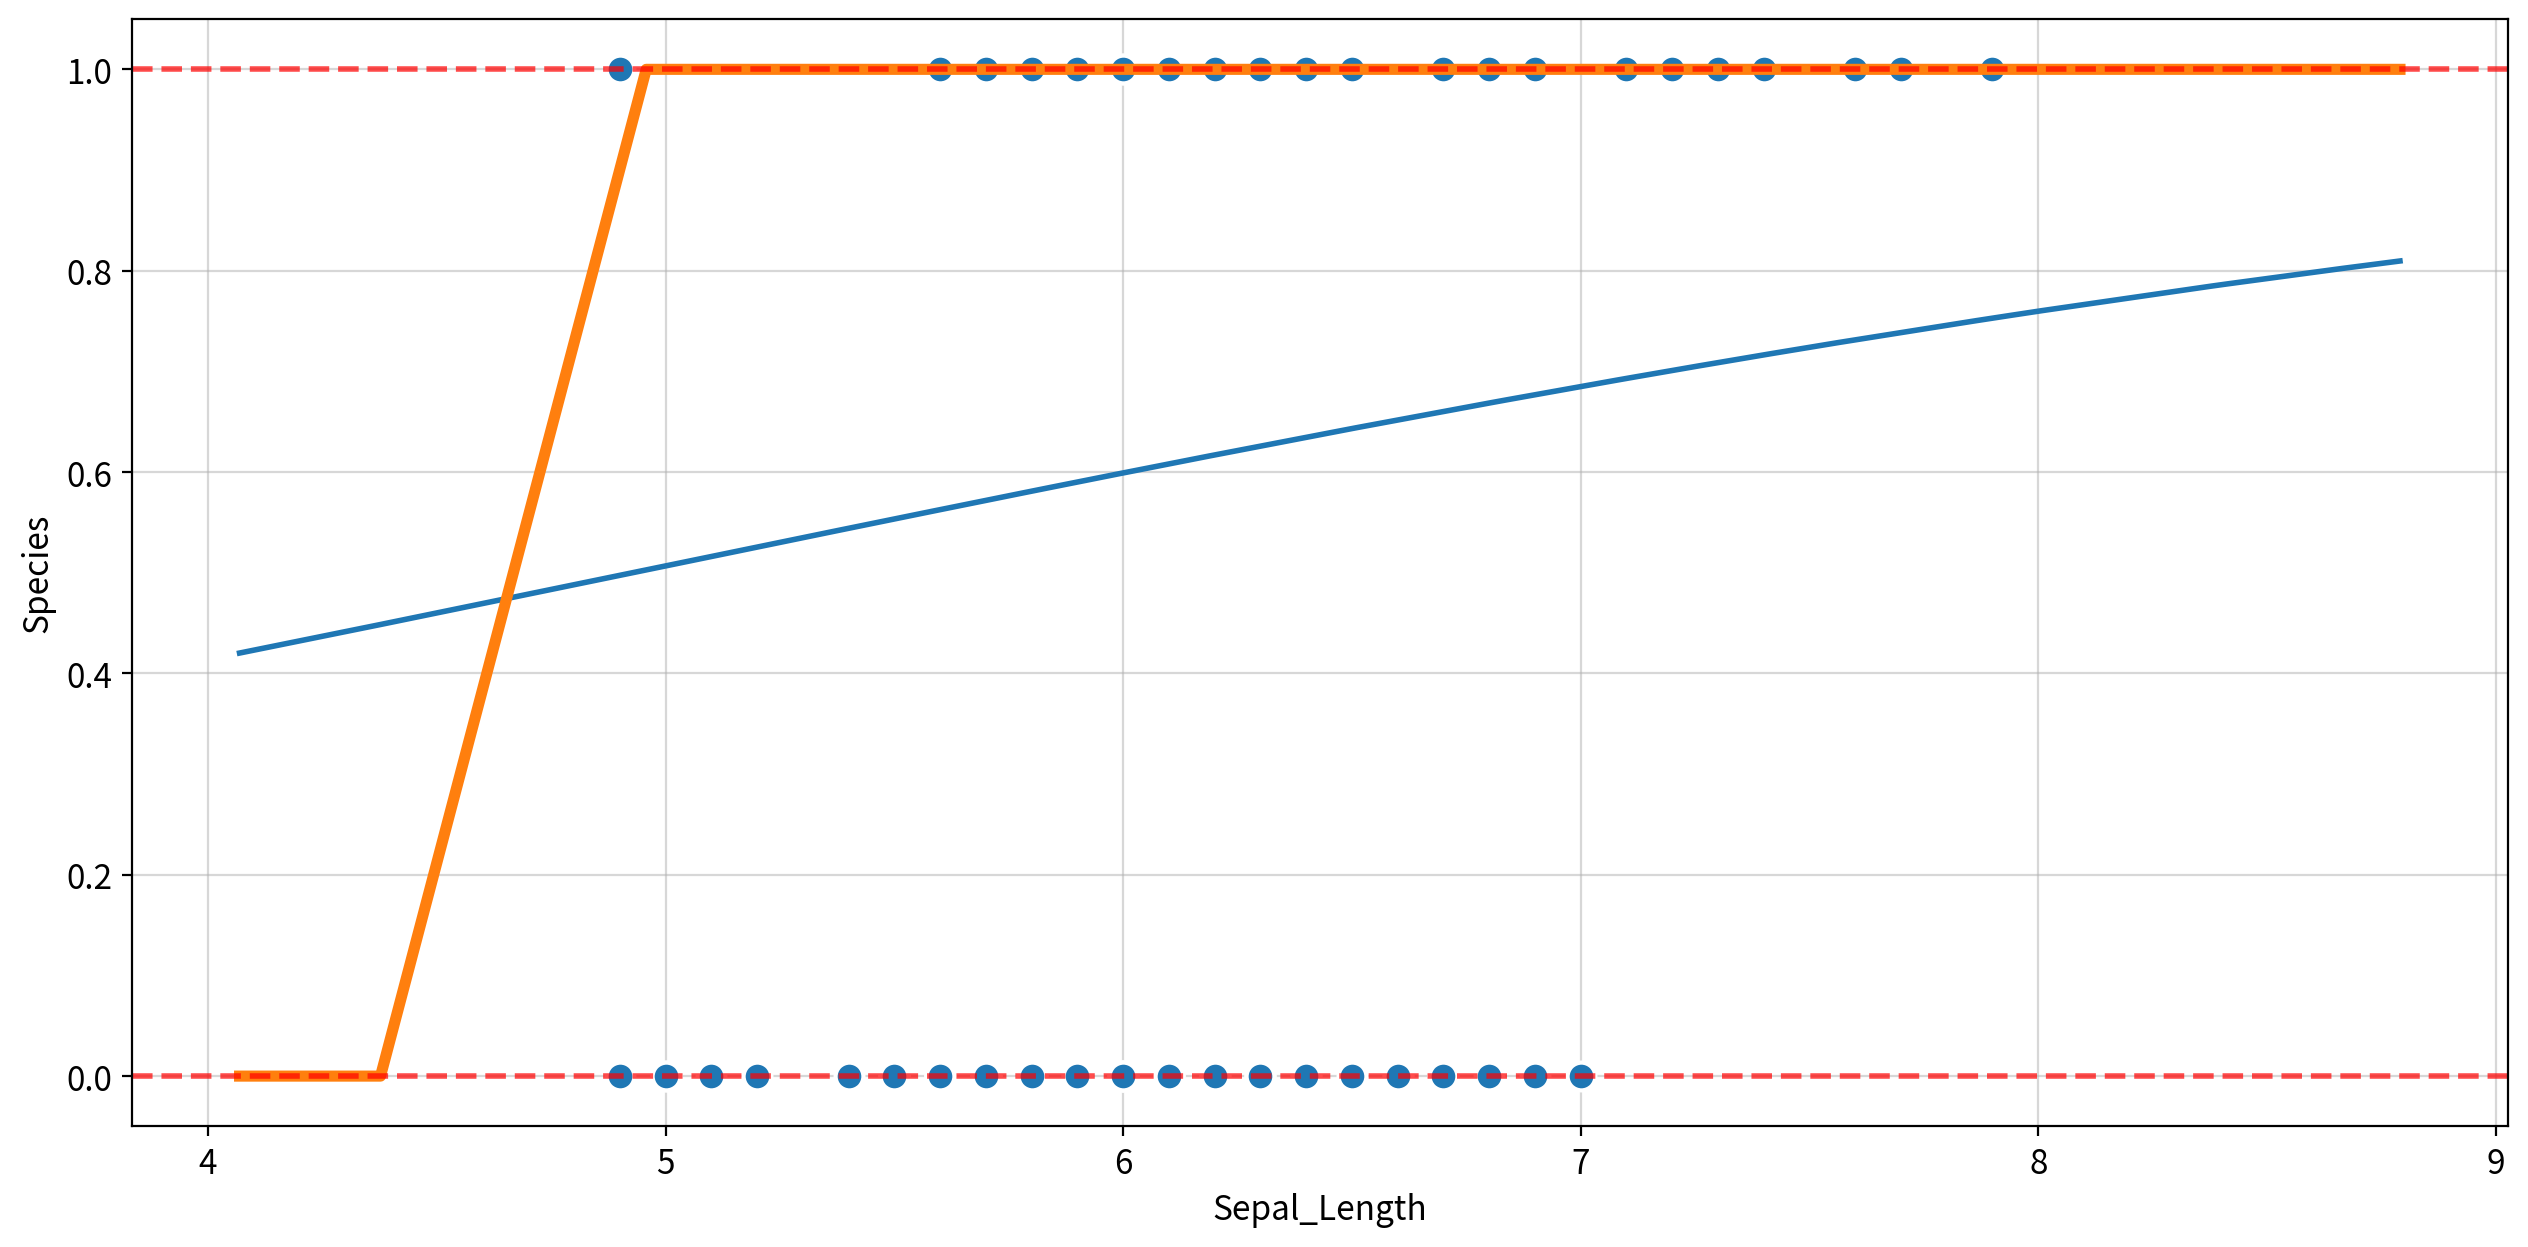

In [39]:
# 시각화 : 실제 관측치(0/1) + 시그모이드를 통과시킨 확률 + 임계값 적용 결과
fig, ax = my_plot.init()

# 실제 관측치는 0 또는 1, 두 개의 높이에만 찍힌다.
my_plot.scatterplot(df, x='Sepal_Length', y='Species', ax=ax)

# 직선의 예측값을 시그모이드에 통과시킨 확률 => 0과 1 사이에 머무른다.
my_plot.lineplot(sample, x='Sepal_Length', y='σ(z)', ax=ax)

# 확률을 반올림(임계값 0.5)한 최종 분류 결과
my_plot.lineplot(sample, x='Sepal_Length', y='result', linewidth=4, ax=ax)

# 확률이 존재할 수 있는 범위(0~1)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.7)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)

my_plot.show()

- 인사이트
    - 직선이 뚫고 나가던 0과 1의 벽을 시그모이드가 막아준다.
        - 얇은 곡선 : 직선의 예측값을 시그모이드에 통과시킨 확률, 빨간 점선(0과 1)을 넘지 않는다.
        - 굵은 계단선 : 확률에 임계값 0.5를 적용한 최종 분류 결과
    - 다만 이것은 선형회귀의 직선을 사후에 변환한 것일 뿐으로, 로지스틱회귀는 처음부터 시그모이드를 전제로 a,b를 직접 추정함

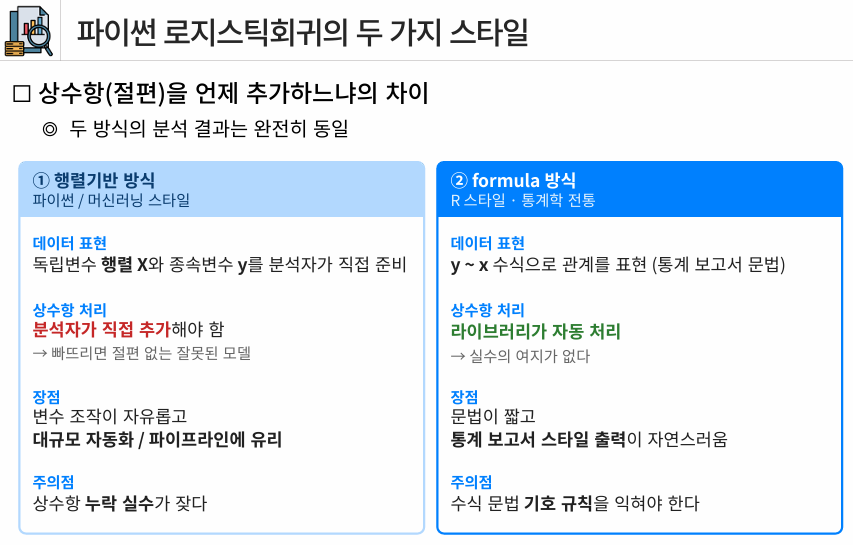

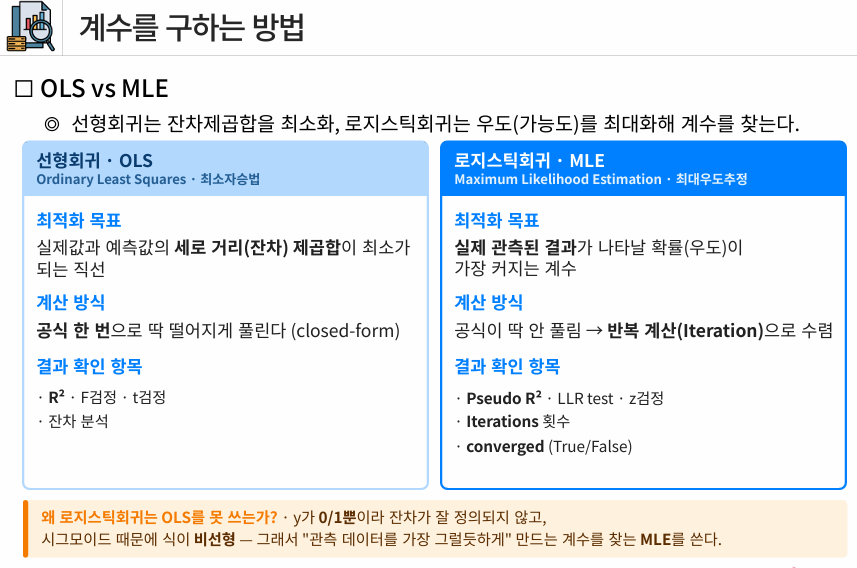

## #04. 행렬 기반 방식의 단순로지스틱 회귀
### 1. 독립변수 행렬 준비
- 독립변수는 2차원 형태(DataFrame)으로 준비한다.

In [40]:
x = df[['Sepal_Length']]
x.head()

,Sepal_Length
0,7.000
1,6.400
2,6.900
3,5.500
4,6.500


### 2. 종속변수 준비
- 종속변수는 Series 객체 형태로 준비한다.
- 반드시 0과 1로 인코딩이 되어 있어야 한다(앞에서 라벨링을 수행한 이유)

In [41]:
y = df['Species']
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

### 3. 상수항 추가
- 시그모이드 안에 들어가는 식이 z = ax+b 형태이므로, b 역햘을 하기 위한 상수항을 추가해야한다.
    - 상수항이 없다면 절편이 0으로 고정된 잘못된 모델이 만들어질 수 있다.

In [42]:
x_input = add_constant(x)
x_input.head()

,const,Sepal_Length
0,1.000,7.000
1,1.000,6.400
2,1.000,6.900
3,1.000,5.500
4,1.000,6.500


### 4. 로지스틱 회귀 분석

In [43]:
# Logit 모델 객체 생성
# -> 이 단계에서는 아직 학습(fit)되지 않음 '모형의 틀'만 만들어짐
model = Logit(y, x_input)

# 모델 적합(fit)
# -> 최대우도추정(MLE)을 반복 계산하여 회귀계수(β)를 추정한다.
fit = model.fit()

# 적합된 모델 객체의 분석 결과 확인
print(fit.summary())

Optimization terminated successfully.
         Current function value: 0.552733
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:21:43   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129

## #05. formaula API 방식의 로지스틱회귀
### 1. 단순로지스틱회귀 구현
- 종속변수 ~ 독립변수 형태의 수식을 문자열로 전달한다.
- 상수항을 자동 처리하므로 직접 추가하지 않아도 된다.

In [44]:
# 학습 모델 객체 생성
model = formula_logit('Species ~ Sepal_Length', data=df)
fit2 = model.fit()
print(fit2.summary())

Optimization terminated successfully.
         Current function value: 0.552733
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        12:21:43   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129

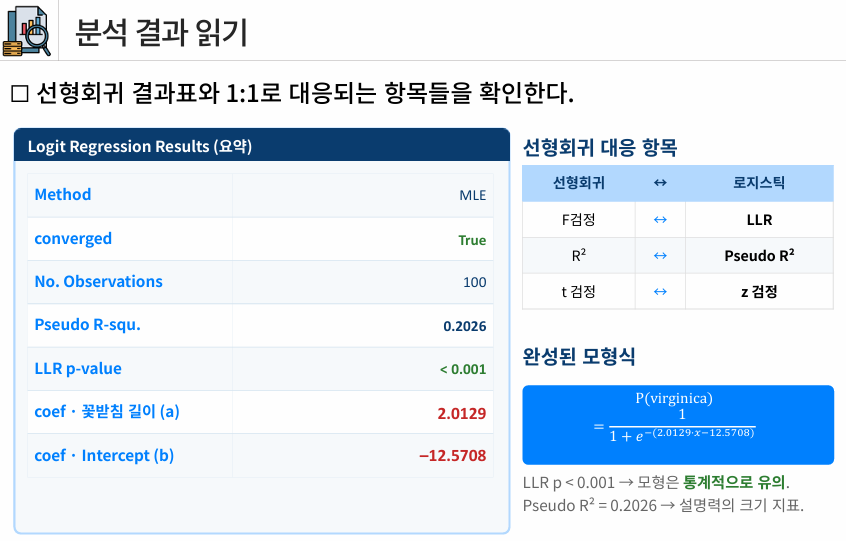

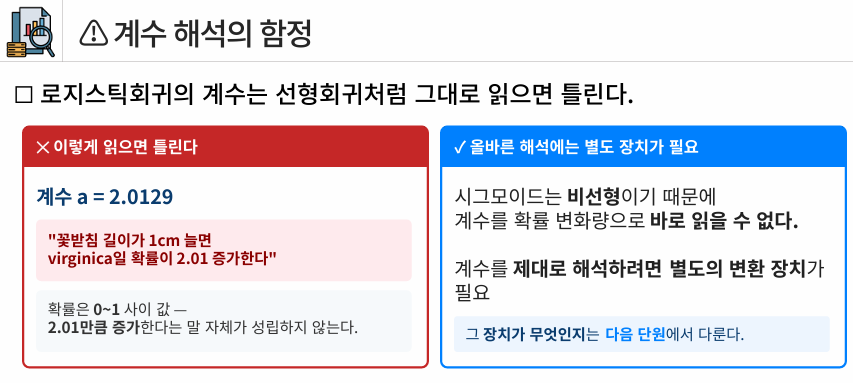

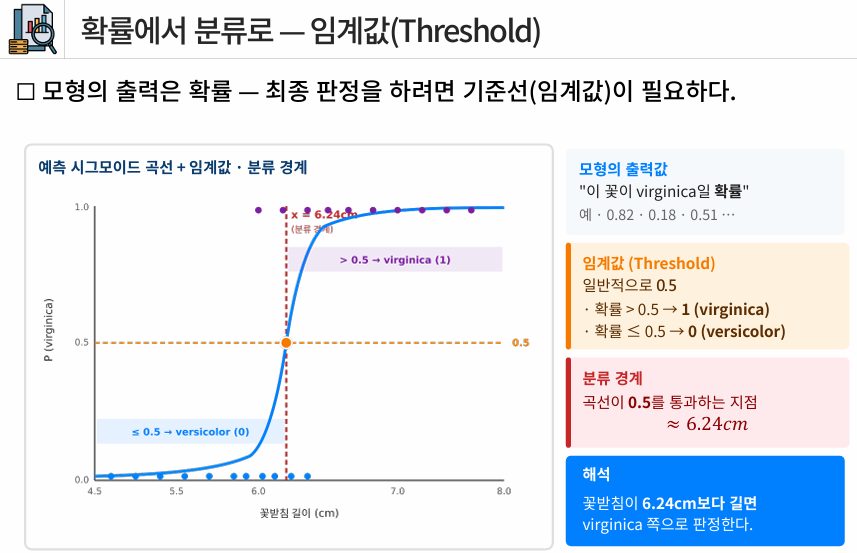

## #06. 실제 데이터와 모형의 예측값 비교
### 1. 예측 확률 생성
- 분석 모형 x에 해당하는 Sepal_Length를 넣으면 virginica일 확률이 계산된다.

In [45]:
# 예측값을 생성하기 위해서는 상수항이 추가된 데이터를 사용해야 한다.
predict_input = add_constant(df[['Sepal_Length']])

new_df = df[['Sepal_Length', 'Species']].copy()

# virginica일 확률
new_df['proba'] = fit.predict(predict_input)

new_df.head()

,Sepal_Length,Species,proba
0,7.000,0,0.820
1,6.400,0,0.577
2,6.900,0,0.789
3,5.500,0,0.182
4,6.500,0,0.626


### 2. 확률을 범주로 변환(임계값 적용)
- 로지스틱회귀의 출력은 확률이므로, 최종적으로 0과 1중 하나로 분류하려면 기준이 필요하다.

In [46]:
threshold = 0.5

# 확률이 임계값을 넘으면 1(virginica), 넘지 못하면 0(versicolor)
new_df['pred'] = (new_df['proba'] > threshold).astype(int)

new_df.head()

,Sepal_Length,Species,proba,pred
0,7.000,0,0.820,1
1,6.400,0,0.577,1
2,6.900,0,0.789,1
3,5.500,0,0.182,0
4,6.500,0,0.626,1


### 3. 분류 경계 확인
- 확률이 정확히 0.5가 되는 지점은 시그모이드의 정의상 z=0인 곳이다.
    - 즉, ax+b=0을 만족하는 x가 0과 1을 가르는 분류 경계가 된다.

In [47]:
a = fit.params['Sepal_Length'] # 기울기
b = fit.params['const']        # 절편

boundary = -b / a

print(f'기울기 a = {a:.4f}, 절편 ㅠ = {b:.4f}')
print(f'분류 경계: 꽃받침 길이 {boundary:.2f}cm')

기울기 a = 2.0129, 절편 ㅠ = -12.5708
분류 경계: 꽃받침 길이 6.25cm


### 4. 시각화 비교

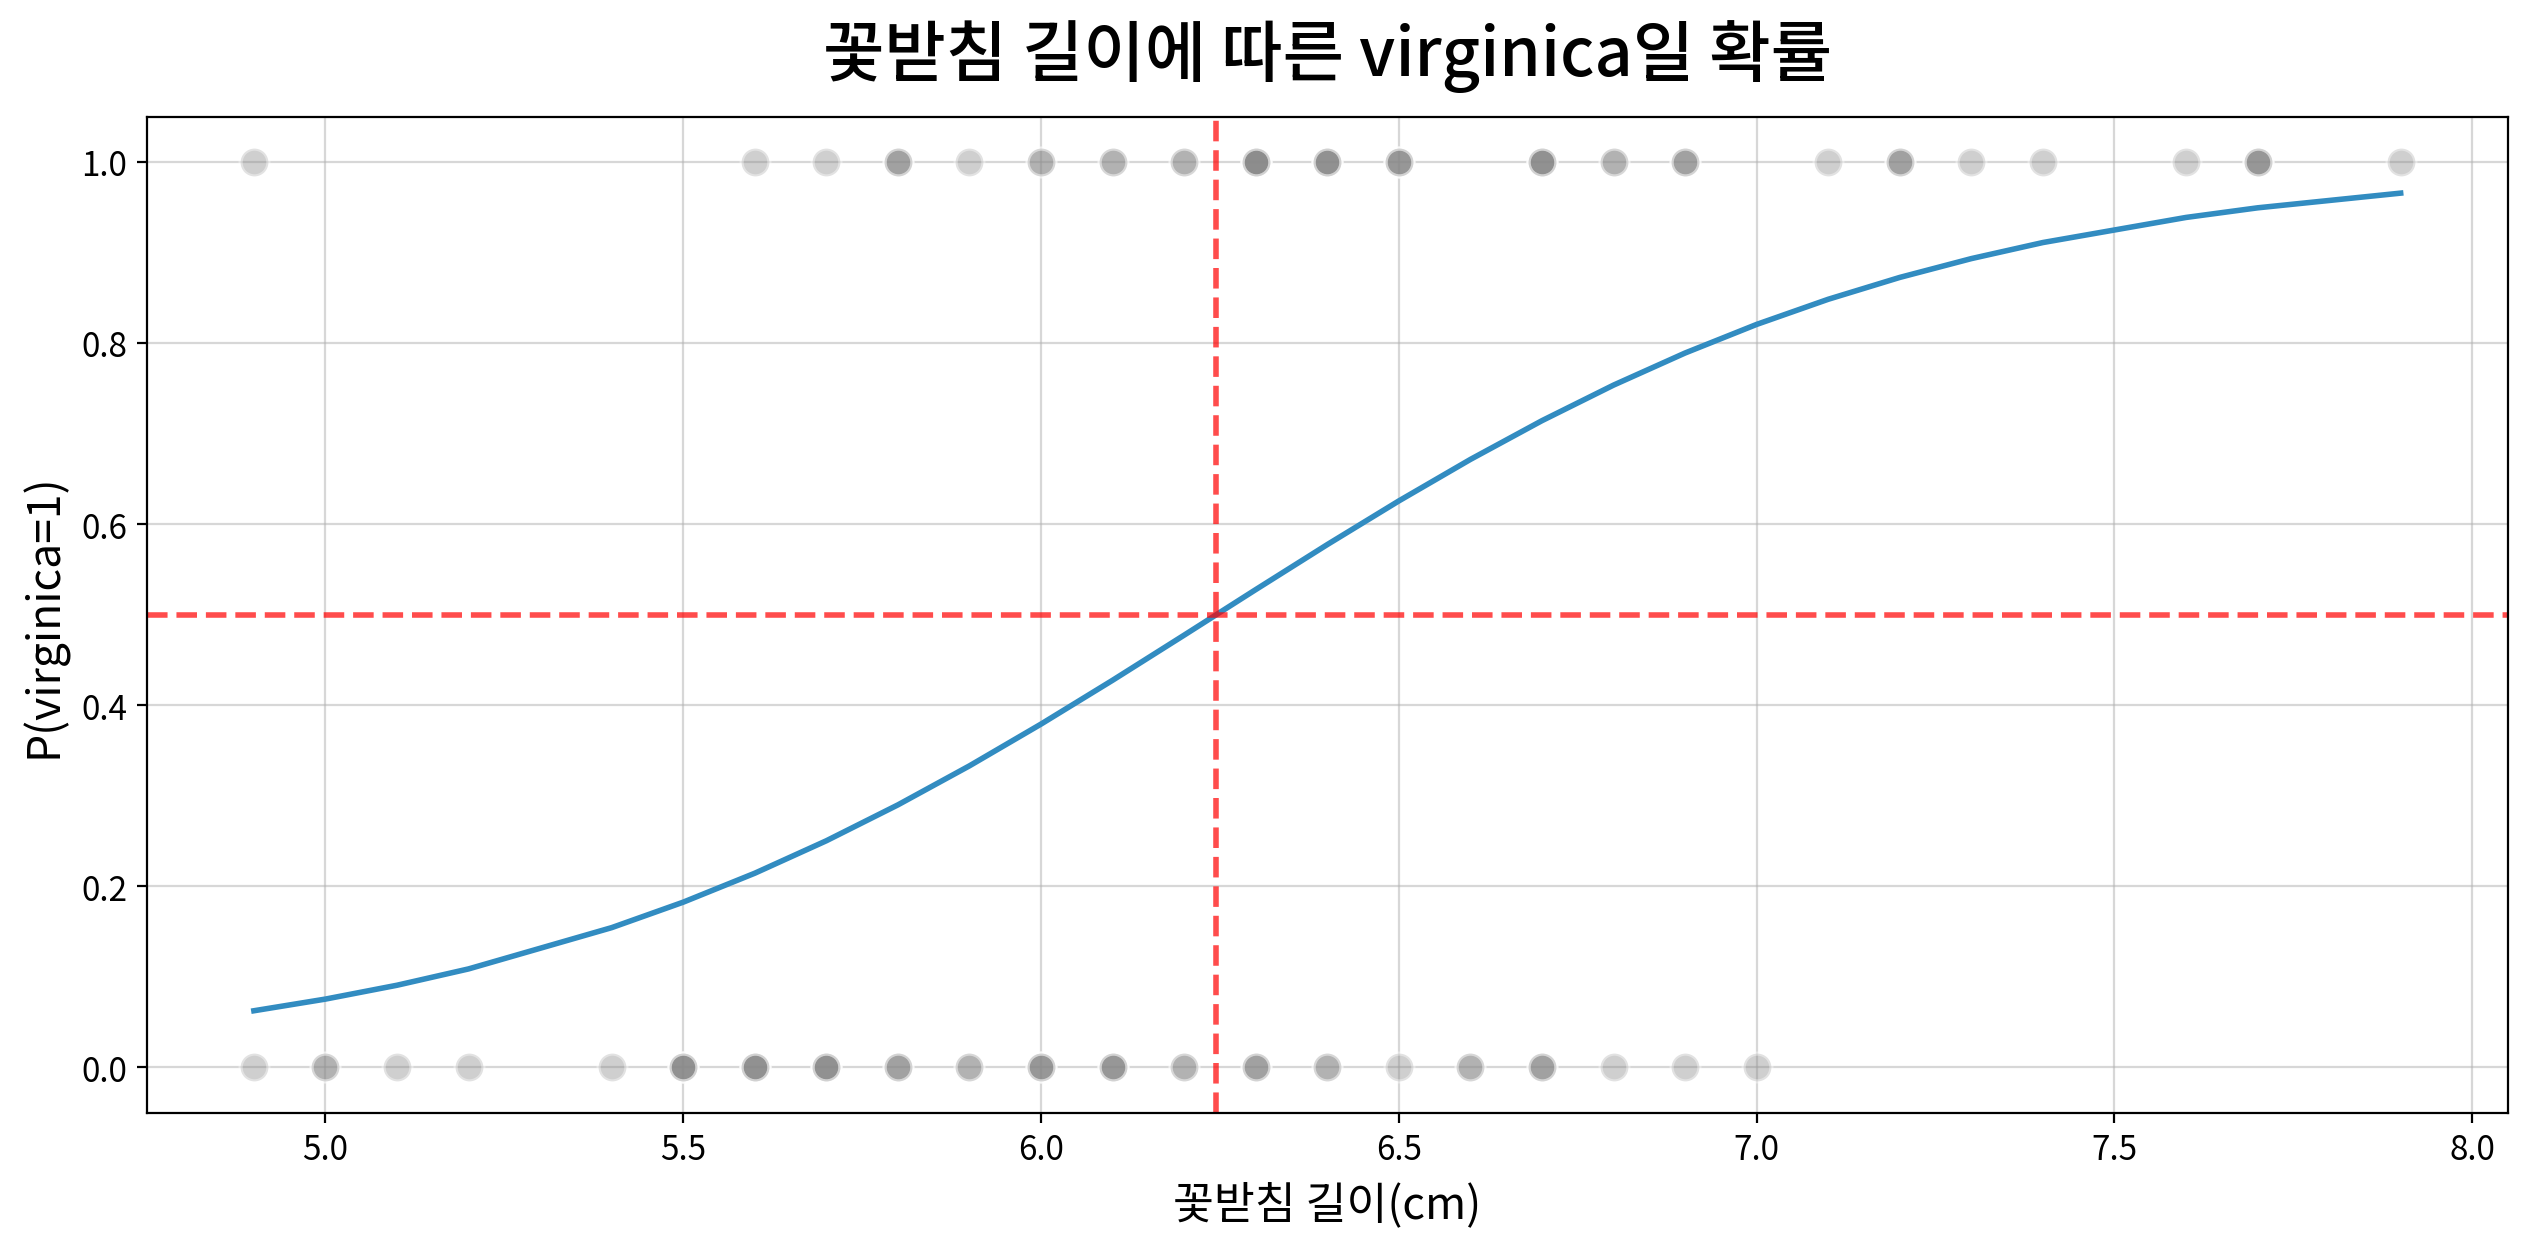

In [48]:
fig, ax = my_plot.init(title='꽃받침 길이에 따른 virginica일 확률', xlabel='꽃받침 길이(cm)', ylabel='P(virginica=1)')

# 실제 관측치 (0 또는 1)
my_plot.scatterplot(df, x='Sepal_Length', y='Species', color='#888888', alpha=0.4, ax=ax)

# 모형이 예측한 확률 곡선(시그모이드)
my_plot.lineplot(new_df, x='Sepal_Length', y='proba', color='#328CC1', ax=ax)

# 임계값(0.5) 기준선과 분류 경계
ax.axhline(y=threshold, color='red', linestyle='--', alpha=0.7)
ax.axvline(x=boundary, color='red', linestyle='--', alpha=0.7)

my_plot.show()

- 인사이트
        - 선형회귀의 직선과 달리 예측 확률이 0과 1 사이에 머무르는 S자 곡선을 그린다.
        - 곡선이 임계값 0.5를 넘어서는 (6.25cm)이 versicolor와 virginica를 가르는 분류 경계이다.
    - 다만 경계 부근에는 회색 점들이 위아래로 섞여있다. 꽃받침 길이 하나만으로는 두 품종을 완벽하게 구분할 수 없다는 뜻이며, 이것이 다중로지스틱회귀(2단원)로 넘어가는 이유가 된다.